<a href="https://www.kaggle.com/code/tensura3607/01-train-resnet-unet-kaggle?scriptVersionId=323053703" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/tensura3607/01-train-resnet-unet-kaggle?scriptVersionId=322971436" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Train ResNet-UNet on Kaggle

Notebook này dùng cho Kaggle. Hỗ trợ các layout dữ liệu phổ biến:

- `DATA_ROOT/images` và `DATA_ROOT/masks`
- `DATA_ROOT/train|val|test/images` và `DATA_ROOT/train|val|test/masks`
- file `.npz` có key ảnh/mask như `images` + `masks`, `x` + `y`, `image` + `mask`

Nếu dữ liệu hoặc source repo nằm ở vị trí khác, set biến môi trường `DATA_ROOT` hoặc `PROJECT_ROOT` trước khi chạy.

In [1]:
from pathlib import Path
import os
import subprocess
import sys


FALL_BACK_URL = "https://github.com/Sura3607/Automated_Abdominal_Multi-Organ_Segmentation_via_Contrastive_Learning_and_Attention_Mechanisms.git"
GITHUB_REPO_URL = os.getenv("GITHUB_REPO_URL", "").strip() or FALL_BACK_URL
GITHUB_BRANCH = os.getenv("GITHUB_BRANCH", "").strip()

try:
    import kagglehub 
except ImportError:
    print("kagglehub chưa có, đang cài đặt để upload Kaggle Model.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])

def clone_or_pull_repo(repo_url, branch=""):
        repo_dir = Path("/kaggle/working/project_repo")
        if (repo_dir / ".git").exists():
            subprocess.check_call(["git", "-C", str(repo_dir), "fetch", "origin"])
            if branch:
                subprocess.check_call(["git", "-C", str(repo_dir), "checkout", branch])
                subprocess.check_call(["git", "-C", str(repo_dir), "pull", "--ff-only", "origin", branch])
            else:
                subprocess.check_call(["git", "-C", str(repo_dir), "pull", "--ff-only"])
        elif not repo_dir.exists():
            clone_cmd = ["git", "clone", "--depth", "1"]
            if branch:
                clone_cmd.extend(["--branch", branch])
            clone_cmd.extend([repo_url, str(repo_dir)])
            subprocess.check_call(clone_cmd)
        if not (repo_dir / "src").exists():
            raise FileNotFoundError(f"Repository was cloned, but src/ was not found: {repo_dir}")
        return repo_dir

def find_project_root():
    if GITHUB_REPO_URL:
        return clone_or_pull_repo(GITHUB_REPO_URL, GITHUB_BRANCH)

    env_root = os.getenv("PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root))
    candidates.extend([Path.cwd(), Path("/kaggle/working")])
    input_root = Path("/kaggle/input")
    if input_root.exists():
        candidates.extend(sorted(input_root.glob("*")))
    for candidate in candidates:
        if (candidate / "src").exists():
            return candidate

    raise FileNotFoundError("Không tìm thấy thư mục src. Hãy attach repo như Kaggle dataset hoặc set PROJECT_ROOT/GITHUB_REPO_URL.")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

Cloning into '/kaggle/working/project_repo'...


PROJECT_ROOT = /kaggle/working/project_repo


In [2]:
import json
import shutil

import torch
from torch import optim

from src.models import DiceCrossEntropyLoss, ResNetUNet
from src.utils import (
    build_segmentation_dataloaders,
    count_parameters,
    evaluate_segmentation,
    fit_segmentation_model,
    get_device,
    load_checkpoint,
    set_seed,
    show_loaded_segmentation_samples,
    show_segmentation_predictions,
    upload_kaggle_model_artifact,
)

set_seed(42)

def find_data_root():
    env_root = os.getenv("DATA_ROOT")
    if env_root and Path(env_root).exists():
        return Path(env_root)
    candidates = [
        Path("/kaggle/input/synapse-processed"),
        PROJECT_ROOT / "Data" / "project_TransUNet" / "data" / "Synapse",
        PROJECT_ROOT / "data" / "Synapse",
    ]
    input_root = Path("/kaggle/input")
    if input_root.exists():
        candidates.extend(path for path in input_root.rglob("Synapse") if path.is_dir())
        candidates.extend(path.parent for path in input_root.rglob("train_npz") if path.is_dir())
    for candidate in candidates:
        if (candidate / "train_npz").exists() and (candidate / "test_vol_h5").exists():
            return candidate
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return input_root

DATA_ROOT = find_data_root()

NUM_CLASSES = int(os.getenv("NUM_CLASSES", "9"))
IMAGE_SIZE = (224, 224)
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "12"))
EPOCHS = int(os.getenv("EPOCHS", "120"))
LR = float(os.getenv("LR", "1e-4"))
WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "1e-4"))
NUM_WORKERS = int(os.getenv("NUM_WORKERS", "2"))
EARLY_STOPPING_PATIENCE = int(os.getenv("EARLY_STOPPING_PATIENCE", "20"))
EARLY_STOPPING_MIN_DELTA = float(os.getenv("EARLY_STOPPING_MIN_DELTA", "1e-4"))
USE_PRETRAINED_ENCODER = os.getenv("USE_PRETRAINED_ENCODER", "1") == "1"
HU_WINDOW = (-125.0, 275.0) if os.getenv("USE_HU_WINDOW", "1") == "1" else None
CONTRASTIVE_TEMPERATURE = float(os.getenv("CONTRASTIVE_TEMPERATURE", "0.1"))
CONTRASTIVE_MAX_SAMPLES = int(os.getenv("CONTRASTIVE_MAX_SAMPLES", "2048"))
CONTRASTIVE_INCLUDE_BACKGROUND = os.getenv("CONTRASTIVE_INCLUDE_BACKGROUND", "0") == "1"

KAGGLE_USERNAME = os.getenv("KAGGLE_USERNAME", "tensura3607")
KAGGLE_MODEL_SLUG = os.getenv("KAGGLE_MODEL_SLUG", "abdominal-multi-organ-segmentation")
KAGGLE_MODEL_FRAMEWORK = os.getenv("KAGGLE_MODEL_FRAMEWORK", "pyTorch")
BASE_KAGGLE_MODEL_VARIATION = os.getenv("KAGGLE_MODEL_VARIATION", "resnet-unet")
KAGGLE_MODEL_LICENSE = os.getenv("KAGGLE_MODEL_LICENSE", "Apache 2.0")
PUBLISH_TO_KAGGLE_MODEL = os.getenv("PUBLISH_TO_KAGGLE_MODEL", "1") == "1"
ARTIFACT_ROOT = Path("/kaggle/working") / KAGGLE_USERNAME / "models" / "resnet_unet" if Path("/kaggle").exists() else PROJECT_ROOT / "artifacts" / KAGGLE_USERNAME / "resnet_unet"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

CONTRASTIVE_VARIANTS = [
    {"label": "cw0", "weight": 0.0, "variation": BASE_KAGGLE_MODEL_VARIATION},
    {"label": "cw001", "weight": 0.01, "variation": f"{BASE_KAGGLE_MODEL_VARIATION}-cw001"},
    {"label": "cw003", "weight": 0.03, "variation": f"{BASE_KAGGLE_MODEL_VARIATION}-cw003"},
    {"label": "cw005", "weight": 0.05, "variation": f"{BASE_KAGGLE_MODEL_VARIATION}-cw005"},
]

print(f"DATA_ROOT = {DATA_ROOT}")
print(f"ARTIFACT_ROOT = {ARTIFACT_ROOT}")
print(f"KAGGLE_USERNAME = {KAGGLE_USERNAME}")
print(f"PUBLISH_TO_KAGGLE_MODEL = {PUBLISH_TO_KAGGLE_MODEL}")
print(f"USE_PRETRAINED_ENCODER = {USE_PRETRAINED_ENCODER}")
print(f"BATCH_SIZE = {BATCH_SIZE}, NUM_WORKERS = {NUM_WORKERS}, EPOCHS = {EPOCHS}")
print(f"EARLY_STOPPING_PATIENCE = {EARLY_STOPPING_PATIENCE}")
print(f"CONTRASTIVE_TEMPERATURE = {CONTRASTIVE_TEMPERATURE}")
print(f"CONTRASTIVE_MAX_SAMPLES = {CONTRASTIVE_MAX_SAMPLES}")
print(f"CONTRASTIVE_INCLUDE_BACKGROUND = {CONTRASTIVE_INCLUDE_BACKGROUND}")
print("Contrastive sweep variations:")
for variant in CONTRASTIVE_VARIANTS:
    handle = f"{KAGGLE_USERNAME}/{KAGGLE_MODEL_SLUG}/{KAGGLE_MODEL_FRAMEWORK}/{variant['variation']}"
    print(f"- {variant['label']}: weight={variant['weight']} -> {handle}")
print("External downloads:")
print("- kagglehub package for Kaggle Model upload")
print("- torchvision ResNet-50 ImageNet-1K weights when USE_PRETRAINED_ENCODER=1")

DATA_ROOT = /kaggle/input/datasets/tensura3607/synapse-multi-organ/Synapse
ARTIFACT_ROOT = /kaggle/working/tensura3607/models/resnet_unet
KAGGLE_USERNAME = tensura3607
PUBLISH_TO_KAGGLE_MODEL = True
USE_PRETRAINED_ENCODER = True
BATCH_SIZE = 12, NUM_WORKERS = 2, EPOCHS = 120
EARLY_STOPPING_PATIENCE = 20
CONTRASTIVE_TEMPERATURE = 0.1
CONTRASTIVE_MAX_SAMPLES = 2048
CONTRASTIVE_INCLUDE_BACKGROUND = False
Contrastive sweep variations:
- cw0: weight=0.0 -> tensura3607/abdominal-multi-organ-segmentation/pyTorch/resnet-unet
- cw001: weight=0.01 -> tensura3607/abdominal-multi-organ-segmentation/pyTorch/resnet-unet-cw001
- cw003: weight=0.03 -> tensura3607/abdominal-multi-organ-segmentation/pyTorch/resnet-unet-cw003
- cw005: weight=0.05 -> tensura3607/abdominal-multi-organ-segmentation/pyTorch/resnet-unet-cw005
External downloads:
- kagglehub package for Kaggle Model upload
- torchvision ResNet-50 ImageNet-1K weights when USE_PRETRAINED_ENCODER=1


{'train': 1866, 'val': 345, 'test': 1568}
Batch image shape: (12, 3, 224, 224)
Batch mask shape: (12, 224, 224)
Mask labels in first batch: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Train samples after loading labels: [[0, 1], [0, 1, 5], [0, 1, 5, 7]]


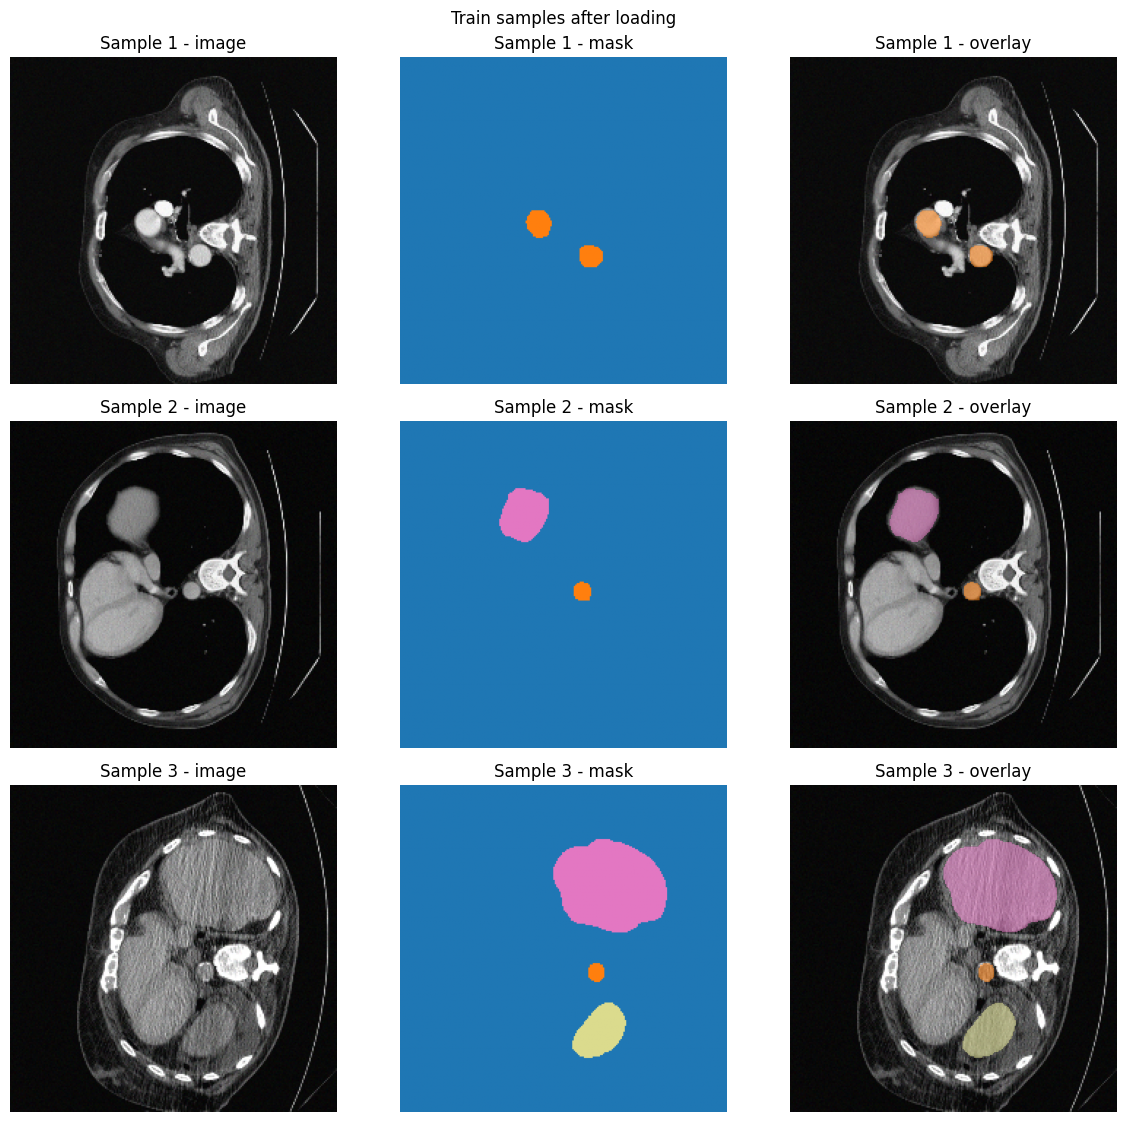

Test samples after loading labels: [[0, 5], [0, 5], [0, 5]]


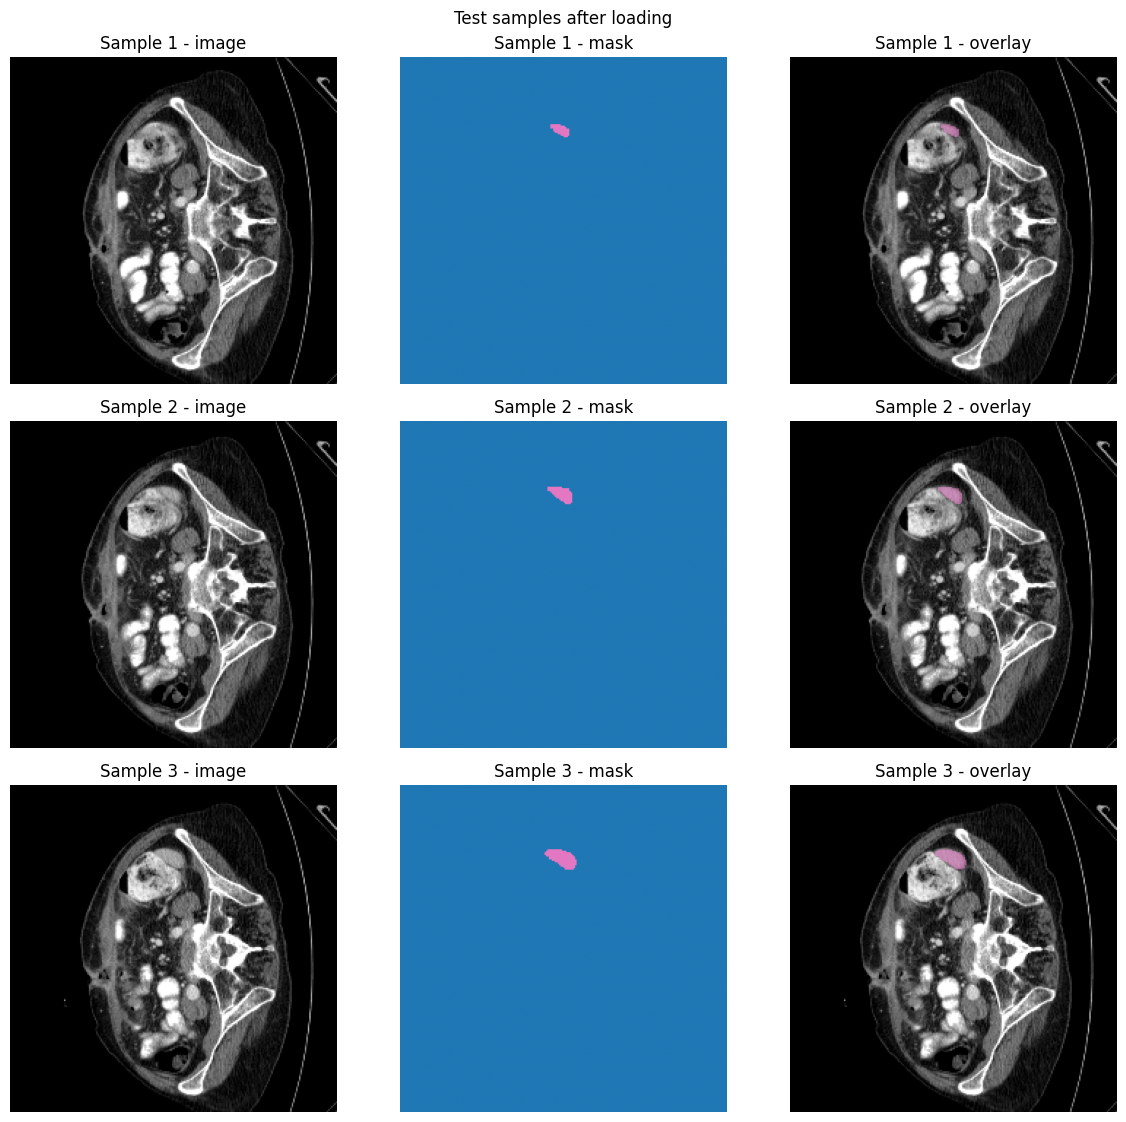

In [3]:
loaders, records = build_segmentation_dataloaders(
    data_root=DATA_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    train_ratio=0.70,
    val_ratio=0.15,
    seed=42,
    hu_window=HU_WINDOW,
)

print({split: len(items) for split, items in records.items()})
images, masks = next(iter(loaders["train"]))
print("Batch image shape:", tuple(images.shape))
print("Batch mask shape:", tuple(masks.shape))
print("Mask labels in first batch:", torch.unique(masks).tolist())

show_loaded_segmentation_samples(
    loaders["train"],
    max_samples=3,
    num_classes=NUM_CLASSES,
    title="Train samples after loading",
)
show_loaded_segmentation_samples(
    loaders["test"],
    max_samples=3,
    num_classes=NUM_CLASSES,
    title="Test samples after loading",
)

In [4]:
device = get_device()
criterion = DiceCrossEntropyLoss()
sweep_results = []

print(f"Device: {device}")

def build_resnet_unet():
    return ResNetUNet(
        num_classes=NUM_CLASSES,
        in_channels=3,
        pretrained_encoder=USE_PRETRAINED_ENCODER,
    ).to(device)

def train_evaluate_publish_variant(variant):
    set_seed(42)
    model = build_resnet_unet()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    artifact_dir = ARTIFACT_ROOT / variant["variation"]
    artifact_dir.mkdir(parents=True, exist_ok=True)
    best_path = artifact_dir / "best_resnet_unet.pt"

    print("=" * 80)
    print(f"Training ResNet-UNet variant {variant['label']} ({variant['variation']})")
    print(f"contrastive_weight = {variant['weight']}")
    print(f"Artifact dir = {artifact_dir}")
    print(f"Trainable params: {count_parameters(model):,}")

    history = fit_segmentation_model(
        model=model,
        loaders=loaders,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_classes=NUM_CLASSES,
        epochs=EPOCHS,
        checkpoint_path=best_path,
        use_amp=True,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
        contrastive_weight=variant["weight"],
        contrastive_temperature=CONTRASTIVE_TEMPERATURE,
        contrastive_max_samples=CONTRASTIVE_MAX_SAMPLES,
        contrastive_include_background=CONTRASTIVE_INCLUDE_BACKGROUND,
    )

    load_checkpoint(best_path, model=model, map_location=device)
    test_metrics = evaluate_segmentation(model, loaders["test"], criterion, device, NUM_CLASSES)
    print("Test metrics")
    print(f"loss      : {test_metrics['loss']:.4f}")
    print(f"mean Dice : {test_metrics['dice_mean']:.4f}")
    print(f"mean IoU  : {test_metrics['iou_mean']:.4f}")
    print(f"pixel acc : {test_metrics['pixel_acc']:.4f}")
    print("Dice per class:", [round(x, 4) for x in test_metrics["dice_per_class"]])
    print("IoU per class :", [round(x, 4) for x in test_metrics["iou_per_class"]])

    (artifact_dir / "test_metrics.json").write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")
    (artifact_dir / "history.json").write_text(json.dumps(history, indent=2), encoding="utf-8")
    model_info = {
        "owner": KAGGLE_USERNAME,
        "model_name": "resnet_unet_synapse",
        "architecture": "ResNetUNet",
        "kaggle_model_variation": variant["variation"],
        "contrastive_label": variant["label"],
        "contrastive_weight": variant["weight"],
        "contrastive_temperature": CONTRASTIVE_TEMPERATURE,
        "contrastive_max_samples": CONTRASTIVE_MAX_SAMPLES,
        "contrastive_include_background": CONTRASTIVE_INCLUDE_BACKGROUND,
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs_requested": EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "pretrained_encoder": USE_PRETRAINED_ENCODER,
        "checkpoint": str(best_path),
        "data_root": str(DATA_ROOT),
        "test_metrics": test_metrics,
    }
    (artifact_dir / "model_info.json").write_text(json.dumps(model_info, indent=2), encoding="utf-8")
    archive_path = shutil.make_archive(str(ARTIFACT_ROOT / f"{variant['variation']}_artifact"), "zip", artifact_dir)
    print(f"Saved Kaggle model artifact folder: {artifact_dir}")
    print(f"Saved Kaggle model artifact zip: {archive_path}")

    uploaded_handle = None
    if PUBLISH_TO_KAGGLE_MODEL:
        version_notes = (
            f"ResNet-UNet Synapse contrastive sweep {variant['label']} "
            f"(weight={variant['weight']}). Test Dice={test_metrics['dice_mean']:.4f}, "
            f"IoU={test_metrics['iou_mean']:.4f}."
        )
        uploaded_handle = upload_kaggle_model_artifact(
            local_model_dir=artifact_dir,
            owner=KAGGLE_USERNAME,
            model_slug=KAGGLE_MODEL_SLUG,
            framework=KAGGLE_MODEL_FRAMEWORK,
            variation=variant["variation"],
            version_notes=version_notes,
            license_name=KAGGLE_MODEL_LICENSE,
        )
        print(f"Uploaded new Kaggle Model version: https://www.kaggle.com/models/{uploaded_handle}")
    else:
        print("Skipped Kaggle Model upload because PUBLISH_TO_KAGGLE_MODEL=0")

    result = {
        "model": "ResNet-UNet",
        "architecture": "ResNetUNet",
        "contrastive_label": variant["label"],
        "contrastive_weight": variant["weight"],
        "variation": variant["variation"],
        "artifact_dir": str(artifact_dir),
        "checkpoint_path": str(best_path),
        "uploaded_handle": uploaded_handle,
        "test_metrics": test_metrics,
    }
    del optimizer, model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result

for variant in CONTRASTIVE_VARIANTS:
    sweep_results.append(train_evaluate_publish_variant(variant))

print("Completed ResNet-UNet contrastive sweep.")

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


Training ResNet-UNet variant cw0 (resnet-unet)
contrastive_weight = 0.0
Artifact dir = /kaggle/working/tensura3607/models/resnet_unet/resnet-unet
Trainable params: 38,490,313


/kaggle/working/project_repo/src/utils.py:859: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if use_amp and device.type == "cuda" else None
/kaggle/working/project_repo/src/utils.py:754: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 001/120 | train_loss=1.2526 train_dice=0.0816 | val_loss=1.0430 val_dice=0.1078 val_iou=0.0947
Saved best checkpoint: /kaggle/working/tensura3607/models/resnet_unet/resnet-unet/best_resnet_unet.pt
Epoch 002/120 | train_loss=0.9700 train_dice=0.1064 | val_loss=0.9152 val_dice=0.0819 val_iou=0.0602
No validation Dice improvement (1/20).
Epoch 003/120 | train_loss=0.8080 train_dice=0.1538 | val_loss=0.7431 val_dice=0.1587 val_iou=0.1211
Saved best checkpoint: /kaggle/working/tensura3607/models/resnet_unet/resnet-unet/best_resnet_unet.pt
Epoch 004/120 | train_loss=0.6736 train_dice=0.1945 | val_loss=0.6132 val_dice=0.1800 val_iou=0.1482
Saved best checkpoint: /kaggle/working/tensura3607/models/resnet_unet/resnet-unet/best_resnet_unet.pt
Epoch 005/120 | train_loss=0.5722 train_dice=0.2856 | val_loss=0.5599 val_dice=0.2748 val_iou=0.2230
Saved best checkpoint: /kaggle/working/tensura3607/models/resnet_unet/resnet-unet/best_resnet_unet.pt
Epoch 006/120 | train_loss=0.4997 train_dice=0.4

...


Uploading: 100%|██████████| 462M/462M [00:04<00:00, 93.0MB/s]

Upload successful: /kaggle/working/tensura3607/models/resnet_unet/resnet-unet-cw005/best_resnet_unet.pt (441MB)
Starting upload for file /kaggle/working/tensura3607/models/resnet_unet/resnet-unet-cw005/history.json



Uploading: 100%|██████████| 80.0k/80.0k [00:00<00:00, 206kB/s]

Upload successful: /kaggle/working/tensura3607/models/resnet_unet/resnet-unet-cw005/history.json (78KB)


Your model instance has been created.
Files are being processed...
See at: https://api.kaggle.com/models/tensura3607/abdominal-multi-organ-segmentation/pyTorch/resnet-unet-cw005
Uploaded new Kaggle Model version: https://www.kaggle.com/models/tensura3607/abdominal-multi-organ-segmentation/pyTorch/resnet-unet-cw005
Completed ResNet-UNet contrastive sweep.


Saved sweep summary: /kaggle/working/tensura3607/models/resnet_unet/resnet_unet_contrastive_sweep_summary.csv


,model,variation,contrastive_label,contrastive_weight,loss,mean_dice,mean_iou,pixel_acc,checkpoint_path,uploaded_handle
0,ResNet-UNet,resnet-unet,cw0,0.00,0.346372,0.820869,0.712302,0.992519,/kaggle/working/tensura3607/models/resnet_unet...,tensura3607/abdominal-multi-organ-segmentation...
1,ResNet-UNet,resnet-unet-cw001,cw001,0.01,0.350764,0.812490,0.704461,0.992721,/kaggle/working/tensura3607/models/resnet_unet...,tensura3607/abdominal-multi-organ-segmentation...
3,ResNet-UNet,resnet-unet-cw005,cw005,0.05,0.348684,0.805341,0.694200,0.992536,/kaggle/working/tensura3607/models/resnet_unet...,tensura3607/abdominal-multi-organ-segmentation...
2,ResNet-UNet,resnet-unet-cw003,cw003,0.03,0.349090,0.801204,0.689031,0.991946,/kaggle/working/tensura3607/models/resnet_unet...,tensura3607/abdominal-multi-organ-segmentation...


Best ResNet-UNet variant: resnet-unet (weight=0.0, Dice=0.8209)


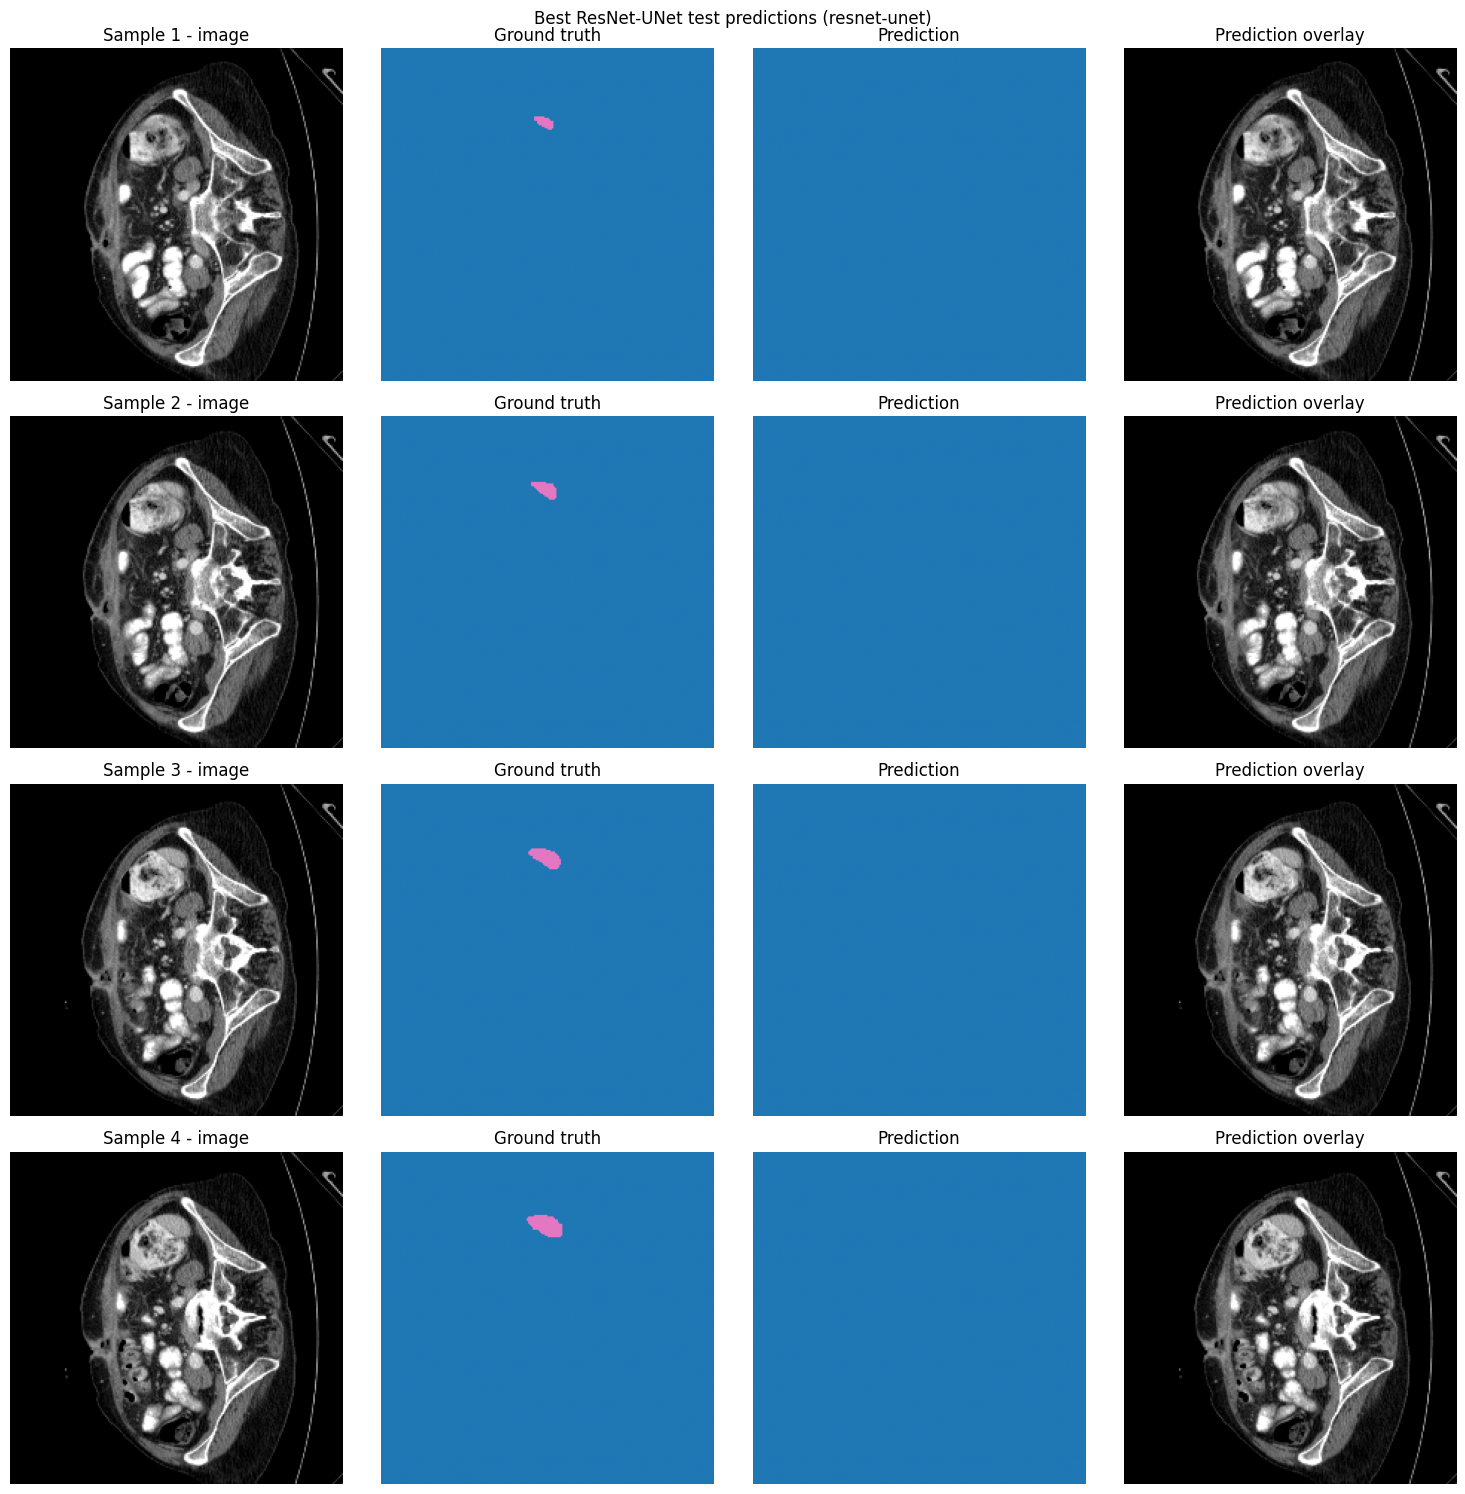

In [5]:
import pandas as pd

sweep_summary_df = pd.DataFrame([
    {
        "model": item["model"],
        "variation": item["variation"],
        "contrastive_label": item["contrastive_label"],
        "contrastive_weight": item["contrastive_weight"],
        "loss": item["test_metrics"]["loss"],
        "mean_dice": item["test_metrics"]["dice_mean"],
        "mean_iou": item["test_metrics"]["iou_mean"],
        "pixel_acc": item["test_metrics"]["pixel_acc"],
        "checkpoint_path": item["checkpoint_path"],
        "uploaded_handle": item["uploaded_handle"],
    }
    for item in sweep_results
]).sort_values("mean_dice", ascending=False)

summary_path = ARTIFACT_ROOT / "resnet_unet_contrastive_sweep_summary.csv"
sweep_summary_df.to_csv(summary_path, index=False)
print(f"Saved sweep summary: {summary_path}")
display(sweep_summary_df)

best_result = max(sweep_results, key=lambda item: item["test_metrics"]["dice_mean"])
print(
    "Best ResNet-UNet variant: "
    f"{best_result['variation']} (weight={best_result['contrastive_weight']}, "
    f"Dice={best_result['test_metrics']['dice_mean']:.4f})"
)

visual_model = build_resnet_unet()
load_checkpoint(best_result["checkpoint_path"], model=visual_model, map_location=device)
show_segmentation_predictions(
    model=visual_model,
    loader=loaders["test"],
    device=device,
    max_samples=4,
    num_classes=NUM_CLASSES,
    title=f"Best ResNet-UNet test predictions ({best_result['variation']})",
)
del visual_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()